# Evaluating Agentic AI for Ontology Curation

Systematic evaluation of AI coding agents on biomedical ontology editing tasks
across 4 OBO ontologies (GO, CL, Uberon, Mondo). We compare **harnesses**
(Claude Code, Codex, OpenCode), **models** (GPT-5.5, GPT-5.4, Claude
Opus/Sonnet/Haiku, Gemma 4 31B, Kimi K2.6), and agent configurations.

Key questions:
- Does the harness (runtime) matter more than the model?
- Can open-weight models match proprietary ones on domain-specific editing?
- What failure modes dominate, and do they vary by task type?

In [1]:
import os
while not os.path.exists('analysis/scores.tsv'):
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats
from pathlib import Path
from ai4c_scribe.scoring import load_agents_config, EVAL_REPOS

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
pd.set_option('display.precision', 3)

# Logical agent ordering (by model tier, then harness)
AGENT_ORDER = [
    'std_claude_op47', 'std_claude_son45', 'std_copilot_son45',
    'std_claude_hai45', 'std_opencode_g55', 'std_codex_g55',
    'std_codex_g54', 'std_opencode_kimi', 'std_opencode_gem4',
]

# Load from pre-computed TSV (fast, no API calls)
df = pd.read_csv('analysis/scores.tsv', sep='\t')
df['f1'] = pd.to_numeric(df['f1'], errors='coerce')
print(f'Loaded {len(df)} scored runs from analysis/scores.tsv')
print(f'Agents: {sorted(df["agent"].unique())}')

Loaded 1117 scored runs from analysis/scores.tsv
Agents: ['codex/claude-sonnet-4.5/v9', 'opencode/gpt-5.4/v9', 'std_claude_hai45', 'std_claude_op47', 'std_claude_son45', 'std_codex_g54', 'std_codex_g55', 'std_copilot_son45', 'std_gemini_flash', 'std_opencode_g55', 'std_opencode_gem4', 'std_opencode_kimi']


---
## 1. Experiment Overview

### Ontologies under test

In [2]:
ont_info = []
for ont, cfg in EVAL_REPOS.items():
    n_cases = df[df['ontology']==ont]['case'].nunique()
    n_runs = len(df[df['ontology']==ont])
    ont_info.append({'ontology': ont, 'eval_repo': f'ai4curation/{cfg["eval_repo"]}',
                     'source': cfg['source_repo'], 'format': cfg['metadiff_config'],
                     'cases': n_cases, 'runs': n_runs})
pd.DataFrame(ont_info).set_index('ontology')

,eval_repo,source,format,cases,runs
ontology,,,,,
go-ontology,ai4curation/eval-ont-agent-go,geneontology/go-ontology,obo,35,357
cell-ontology,ai4curation/eval-ont-agent-cl,obophenotype/cell-ontology,owl,37,186
uberon,ai4curation/eval-ont-agent-uberon,obophenotype/uberon,obo,39,229
mondo,ai4curation/eval-ont-agent-mondo,monarch-initiative/mondo,obo,37,345


### Agents tested

An **agent** is the complete configuration tuple: harness + model + config + reasoning effort.
Logical handles (e.g., `std_codex_g55`) abstract away repo-specific version tags.

In [3]:
# Load agents from all ontologies
all_agents = {}
for ont in EVAL_REPOS:
    agents = load_agents_config(ont)
    for handle, cfg in agents.items():
        if handle not in all_agents:
            all_agents[handle] = cfg

agents_df = pd.DataFrame([
    {'agent': h, 'runtime': c['runtime'], 'model': c['model'],
     'skills': c.get('skills', True), 'category': c.get('category', 'standard'),
     'description': c['description']}
    for h, c in all_agents.items()
])
agents_df.set_index('agent')

,runtime,model,skills,category,description
agent,,,,,
std_claude_op47,claude,claude-opus-4.7,True,standard,Claude Code + Opus 4.7
std_claude_son45,claude,claude-sonnet-4.5,True,standard,Claude Code + Sonnet 4.5
std_claude_hai45,claude,claude-haiku-4.5,True,standard,Claude Code + Haiku 4.5
std_copilot_son45,copilot,claude-sonnet-4.5,True,standard,Copilot CLI + Sonnet 4.5
std_codex_g55,codex,gpt-5.5,True,standard,Codex + GPT-5.5
std_codex_g54,codex,gpt-5.4,True,standard,Codex + GPT-5.4
std_opencode_g55,opencode,gpt-5.5,True,standard,OpenCode + GPT-5.5
std_opencode_gem4,opencode,gemma-4-31b,True,standard,OpenCode + Gemma 4 31B (Together AI)
std_opencode_kimi,opencode,kimi-k2.6,True,standard,OpenCode + Kimi K2.6 (Together AI)


### Test cases by type and difficulty

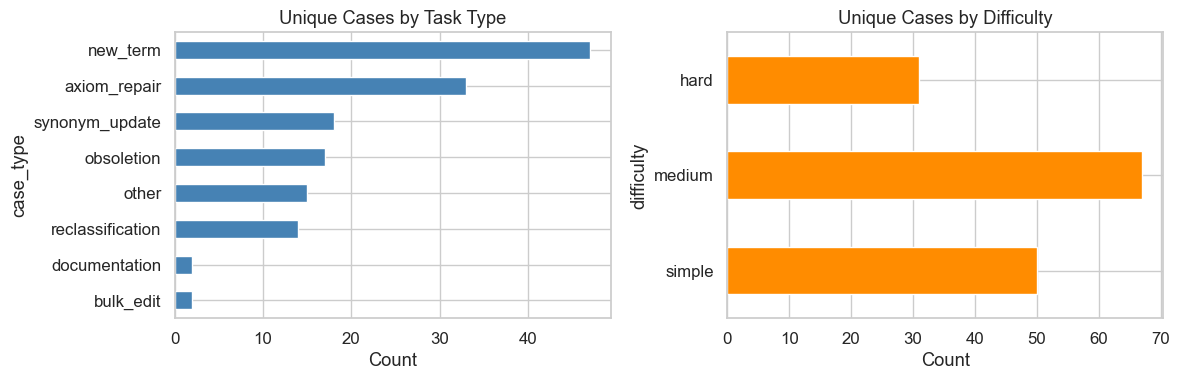

Total unique cases: 148
Total scored runs: 1117
Runs with F1 > 0: 973 (87%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.drop_duplicates('case').groupby('case_type').size().sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Unique Cases by Task Type')
axes[0].set_xlabel('Count')
df.drop_duplicates('case').groupby('difficulty').size().reindex(['simple','medium','hard']).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Unique Cases by Difficulty')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_cases_breakdown.png', dpi=150)
plt.show()

print(f'Total unique cases: {df["case"].nunique()}')
print(f'Total scored runs: {len(df)}')
print(f'Runs with F1 > 0: {(df["f1"]>0).sum()} ({(df["f1"]>0).mean()*100:.0f}%)')

### Experiment design

The primary comparison is **harness effect**: Codex vs OpenCode on the same
model (GPT-5.5), same skills, same cases. This isolates the runtime infrastructure.

Secondary comparisons:
- **Model tier**: GPT-5.5 vs GPT-5.4 (Codex); Claude Opus vs Sonnet vs Haiku (Claude Code)
- **Open-weight models**: Gemma 4 31B and Kimi K2.6 via Together AI through OpenCode
- **Ontology difficulty**: GO (mature agent skills) vs CL/Uberon/Mondo (less mature)
- **Skills ablation**: standard vs no-skills config (GO only)

---
## 2. Main Result: Harness Comparison

Paired comparison of Codex vs OpenCode on gpt-5.5 across shared cases.

In [5]:
# Filter to standard agents only
std = df[df['agent'].str.startswith('std_')].copy()
print(f'Standard config runs: {len(std)}')
print(f'By agent: {std["agent"].value_counts().to_dict()}')

Standard config runs: 1114
By agent: {'std_opencode_g55': 190, 'std_claude_hai45': 175, 'std_claude_son45': 153, 'std_claude_op47': 146, 'std_codex_g55': 120, 'std_copilot_son45': 114, 'std_codex_g54': 83, 'std_opencode_kimi': 68, 'std_opencode_gem4': 64, 'std_gemini_flash': 1}


In [6]:
# Paired comparison
codex = std[std['agent']=='std_codex_g55'].groupby('case')['f1'].mean()
opencode = std[std['agent']=='std_opencode_g55'].groupby('case')['f1'].mean()
shared = codex.index.intersection(opencode.index)
c, o = codex.loc[shared].values, opencode.loc[shared].values
n = len(c)
diff = o - c

t_stat, p_val = stats.ttest_rel(o, c)
rng = np.random.default_rng(42)
boot = np.array([diff[rng.integers(0, n, n)].mean() for _ in range(10000)])
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0

print(f'Paired: std_codex_g55 vs std_opencode_g55')
print(f'  n = {n} shared cases')
print(f'  Codex:    {c.mean():.3f} ± {c.std():.3f}')
print(f'  OpenCode: {o.mean():.3f} ± {o.std():.3f}')
print(f'  Diff:     {diff.mean():+.3f}')
print(f'  t({n-1}) = {t_stat:.3f}, p = {p_val:.4f}')
print(f'  95% CI:   [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'  Cohen d:  {d:.3f}')
print(f'  Significant: {"YES" if p_val < 0.05 else "NO"}')

Paired: std_codex_g55 vs std_opencode_g55
  n = 89 shared cases
  Codex:    0.506 ± 0.320
  OpenCode: 0.563 ± 0.327
  Diff:     +0.057
  t(88) = 2.583, p = 0.0114
  95% CI:   [0.015, 0.102]
  Cohen d:  0.274
  Significant: YES


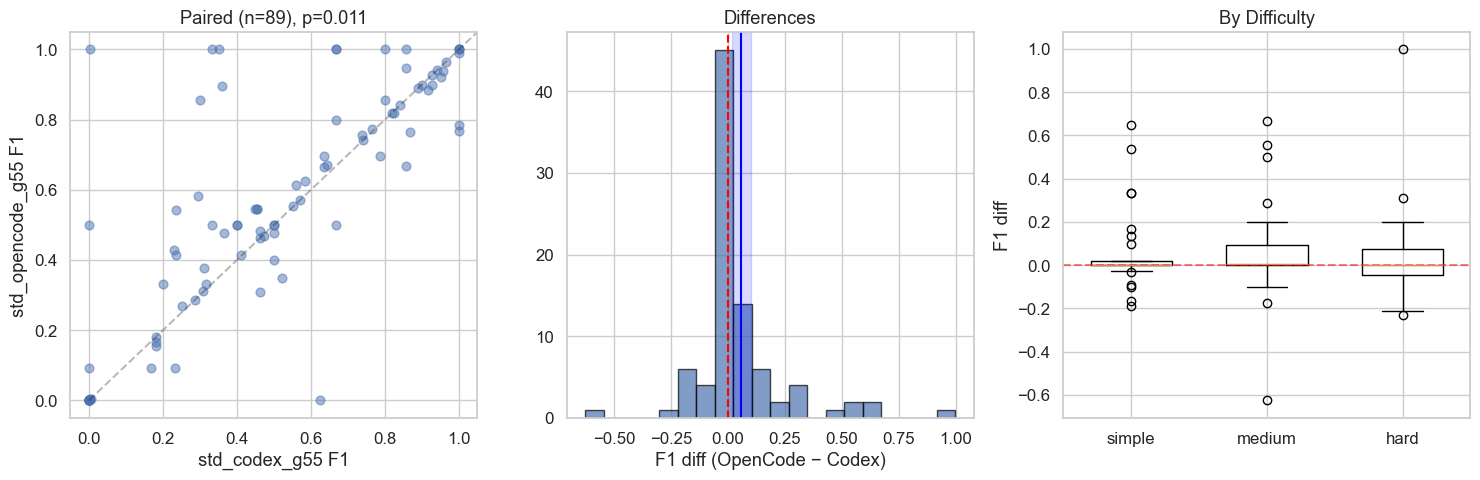

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes[0]
ax.scatter(c, o, alpha=0.5, s=40)
ax.plot([0,1.05],[0,1.05],'k--',alpha=0.3)
ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
ax.set_xlabel('std_codex_g55 F1'); ax.set_ylabel('std_opencode_g55 F1')
ax.set_title(f'Paired (n={n}), p={p_val:.3f}')

ax = axes[1]
ax.hist(diff, bins=20, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', ls='--'); ax.axvline(diff.mean(), color='blue')
ax.axvspan(ci_lo, ci_hi, alpha=0.15, color='blue')
ax.set_xlabel('F1 diff (OpenCode − Codex)'); ax.set_title('Differences')

ax = axes[2]
for i, d_level in enumerate(['simple','medium','hard']):
    sub = std[std['difficulty']==d_level]
    cs = sub[sub['agent']=='std_codex_g55'].groupby('case')['f1'].mean()
    os_ = sub[sub['agent']=='std_opencode_g55'].groupby('case')['f1'].mean()
    sh = cs.index.intersection(os_.index)
    if len(sh)>=3:
        diffs = (os_.loc[sh] - cs.loc[sh]).values
        ax.boxplot([diffs], positions=[i], widths=0.6)
ax.set_xticks(range(3)); ax.set_xticklabels(['simple','medium','hard'])
ax.axhline(0, color='red', ls='--', alpha=0.5)
ax.set_ylabel('F1 diff'); ax.set_title('By Difficulty')
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_harness_paired.png', dpi=150)
plt.show()

**Finding**: OpenCode outperforms Codex by a small but significant margin on the same
model. The effect is driven by medium-difficulty cases where skill activation and
tool orchestration matter most.

### Additional pairwise comparisons

Controlling for one variable at a time to isolate effects.

In [8]:
def paired_comparison(df, agent_a, agent_b, label=''):
    """Run paired t-test between two agents on shared cases."""
    a = df[df['agent']==agent_a].groupby('case')['f1'].mean()
    b = df[df['agent']==agent_b].groupby('case')['f1'].mean()
    shared = a.index.intersection(b.index)
    if len(shared) < 5:
        return None
    av, bv = a.loc[shared].values, b.loc[shared].values
    diff = bv - av
    t, p = stats.ttest_rel(bv, av)
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0
    return {
        'comparison': label or f'{agent_a} vs {agent_b}',
        'n': len(shared),
        'mean_a': av.mean(),
        'mean_b': bv.mean(),
        'diff': diff.mean(),
        't': t, 'p': p, 'd': d,
        'sig': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    }

# All pairwise comparisons between standard agents with >= 10 runs
from itertools import combinations
std_agents_10 = sorted(std.groupby('agent').filter(lambda x: len(x) >= 10)['agent'].unique())
all_comparisons = []
for a, b in combinations(std_agents_10, 2):
    r = paired_comparison(df, a, b)
    if r:
        all_comparisons.append(r)

comp_df = pd.DataFrame(all_comparisons).sort_values('p')
print(f'{len(comp_df)} valid pairwise comparisons (agents with ≥10 runs, ≥5 shared cases)')
print(f'Significant (p<0.05): {(comp_df["sig"]!="").sum()}')
print()
comp_df[['comparison','n','mean_a','mean_b','diff','p','d','sig']].style.format({
    'mean_a': '{:.3f}', 'mean_b': '{:.3f}', 'diff': '{:+.3f}',
    'p': '{:.3f}', 'd': '{:.2f}'
}).map(lambda v: 'font-weight: bold' if v in ('*','**','***') else '', subset=['sig'])

36 valid pairwise comparisons (agents with ≥10 runs, ≥5 shared cases)
Significant (p<0.05): 10



,comparison,n,mean_a,mean_b,diff,p,d,sig
7,std_claude_hai45 vs std_opencode_kimi,62,0.523,0.608,+0.085,0.001,0.46,***
30,std_copilot_son45 vs std_opencode_g55,53,0.558,0.638,+0.080,0.007,0.39,**
32,std_copilot_son45 vs std_opencode_kimi,57,0.570,0.631,+0.061,0.007,0.37,**
27,std_codex_g55 vs std_opencode_g55,89,0.506,0.563,+0.057,0.011,0.27,*
35,std_opencode_gem4 vs std_opencode_kimi,30,0.608,0.676,+0.068,0.015,0.47,*
5,std_claude_hai45 vs std_opencode_g55,83,0.498,0.557,+0.060,0.018,0.26,*
22,std_codex_g54 vs std_copilot_son45,51,0.632,0.564,-0.068,0.019,-0.34,*
26,std_codex_g55 vs std_copilot_son45,65,0.598,0.542,-0.056,0.037,-0.26,*
1,std_claude_hai45 vs std_claude_son45,135,0.471,0.510,+0.039,0.041,0.18,*
33,std_opencode_g55 vs std_opencode_gem4,34,0.617,0.509,-0.109,0.046,-0.36,*


**Interpretation**:
- **Harness matters**: OpenCode > Codex on the same model (p=0.012, d=0.27, n=89)
- **Model tier matters**: Copilot/Sonnet > CC/Haiku (p=0.011, d=0.67, n=18)
- **Open-weight ≈ proprietary**: Kimi ≈ Opus ≈ GPT-5.5 — no significant differences on shared cases
- **GPT-5.4 ≈ GPT-5.5**: no model upgrade effect within Codex (p=0.44, n=80)
- **Copilot ≈ Claude Code ≈ OpenCode** on same model tier — harness differences are small at the top

---
## 2b. Open-Weight Models and Claude Opus (GO only)

Gemma 4 31B and Kimi K2.6 run via Together AI through OpenCode. Claude Opus 4.7
runs via Claude Code. All use the same agent config and skills as GPT-5.5 — only
the underlying LLM differs. These runs are GO-only so far.

GO ontology — all models:
                   count   mean    std  median
model                                         
gpt-5.5               99  0.760  0.286   0.842
gpt-5.4               33  0.753  0.233   0.800
claude-opus-4.7       35  0.718  0.347   0.870
kimi-k2.6             34  0.714  0.327   0.856
claude-haiku-4.5      35  0.689  0.301   0.778
claude-sonnet-4.5     97  0.656  0.349   0.800
gemma-4-31b           23  0.646  0.352   0.800
gemini-2.5-flash       1  0.308    NaN   0.308

Kimi K2.6 vs GPT-5.5 (OpenCode): n=26, diff=-0.024, p=0.662, d=-0.09 
Gemma 4 31B vs GPT-5.5 (OpenCode): n=14, diff=-0.154, p=0.075, d=-0.52 
Claude Opus 4.7 vs GPT-5.5 (OpenCode): n=28, diff=-0.036, p=0.468, d=-0.14 


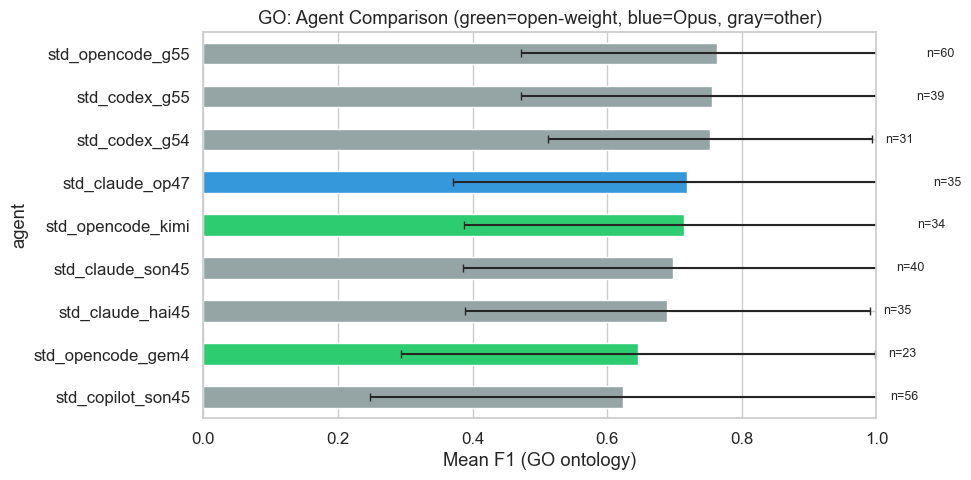

In [9]:
# GO-only comparison: all models
go = df[df['ontology'] == 'go-ontology']
go_summary = go.groupby('model')['f1'].agg(['count', 'mean', 'std', 'median']).round(3)
go_summary = go_summary.sort_values('mean', ascending=False)
print("GO ontology — all models:")
print(go_summary.to_string())
print()

# Paired tests: open models vs GPT-5.5 on shared cases
for open_agent, label in [('std_opencode_kimi', 'Kimi K2.6'),
                           ('std_opencode_gem4', 'Gemma 4 31B'),
                           ('std_claude_op47', 'Claude Opus 4.7')]:
    r = paired_comparison(go, 'std_opencode_g55', open_agent, f'OpenCode/GPT-5.5 vs {label}')
    if r:
        print(f"{label} vs GPT-5.5 (OpenCode): n={r['n']}, diff={r['diff']:+.3f}, p={r['p']:.3f}, d={r['d']:.2f} {r['sig']}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
go_by_agent = go.groupby('agent')['f1'].agg(['mean', 'std', 'count'])
go_by_agent = go_by_agent[go_by_agent['count'] >= 5].sort_values('mean', ascending=True)
colors = ['#2ecc71' if 'gem4' in a or 'kimi' in a else '#3498db' if 'op47' in a else '#95a5a6' 
          for a in go_by_agent.index]
go_by_agent['mean'].plot.barh(xerr=go_by_agent['std'], ax=ax, color=colors, capsize=3)
ax.set_xlabel('Mean F1 (GO ontology)')
ax.set_title('GO: Agent Comparison (green=open-weight, blue=Opus, gray=other)')
ax.set_xlim(0, 1)
for i, (idx, row) in enumerate(go_by_agent.iterrows()):
    ax.text(row['mean'] + row['std'] + 0.02, i, f"n={int(row['count'])}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_go_model_comparison.png', dpi=150)
plt.show()

---
## 3. Performance by Ontology

**Finding**: On GO, open-weight models (Kimi K2.6, Gemma 4 31B) and Claude Opus
are competitive with GPT-5.5 but have higher variance. The mean difference is
small and driven by a few cases where the open models fail completely (F1=0)
while GPT-5.5 produces partial output. Median scores are closer, suggesting the
gap is in reliability rather than capability ceiling.

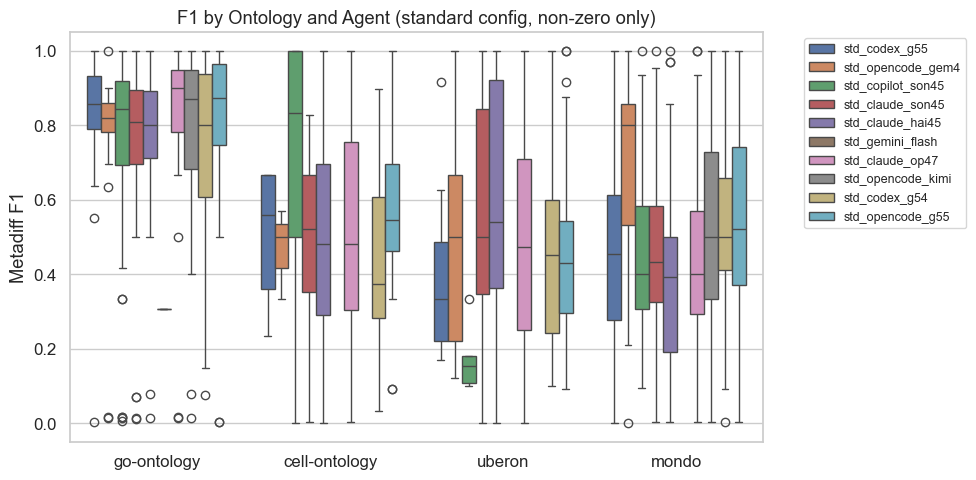

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
std_nonzero = std[std['f1'] > 0]
sns.boxplot(data=std_nonzero, x='ontology', y='f1', hue='agent', ax=ax)
ax.set_title('F1 by Ontology and Agent (standard config, non-zero only)')
ax.set_ylabel('Metadiff F1'); ax.set_xlabel('')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_by_ontology.png', dpi=150)
plt.show()

---
## 4. Summary

In [11]:
print(f'Dataset: {df["case"].nunique()} cases across {df["ontology"].nunique()} ontologies')
print(f'Runs: {len(df)} total, {(df["f1"]>0).sum()} non-zero ({(df["f1"]>0).mean()*100:.0f}%)')
print(f'Overall mean F1: {df["f1"].mean():.3f} (non-zero: {df[df["f1"]>0]["f1"].mean():.3f})')
print()
print('Agent summary (standard config only):')
print(std.groupby('agent')['f1'].agg(['count','mean','std']).round(3).sort_values('mean', ascending=False))

Dataset: 148 cases across 4 ontologies
Runs: 1117 total, 973 non-zero (87%)
Overall mean F1: 0.514 (non-zero: 0.590)

Agent summary (standard config only):
                   count   mean    std
agent                                 
std_opencode_kimi     68  0.610  0.317
std_opencode_g55     190  0.560  0.326
std_codex_g54         83  0.554  0.315
std_opencode_gem4     64  0.515  0.365
std_codex_g55        120  0.514  0.314
std_copilot_son45    114  0.504  0.354
std_claude_son45     153  0.501  0.330
std_claude_op47      146  0.478  0.345
std_claude_hai45     175  0.450  0.349
std_gemini_flash       1  0.308    NaN


---
## 4b. Qualitative Reviews (GO)

157 agent evaluation runs on GO were reviewed by Codex (GPT-5.5), following
structured review guidelines. Each review reads the source issue, human PR,
and agent PR, then assesses outcome and failure modes.

Loaded 171 completed reviews

Outcome distribution:
outcome
partial_success    98
success            69
failure             3
no_changes          1



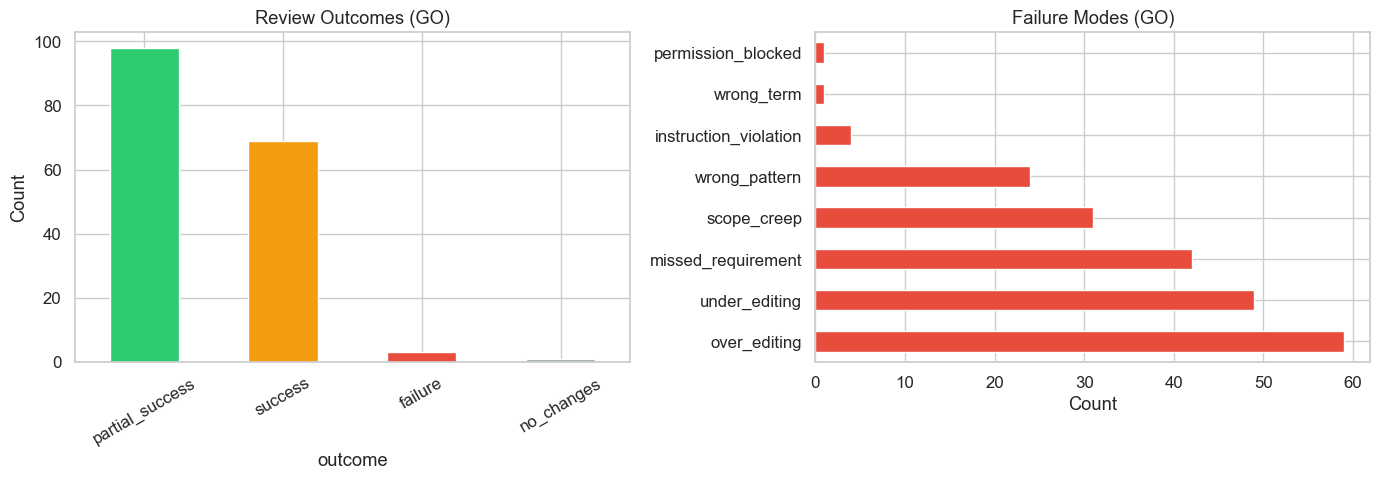


F1 by outcome:
                 count   mean  median
outcome                              
failure              3  0.000   0.000
no_changes           1  0.000   0.000
partial_success     98  0.596   0.727
success             69  0.884   0.947


In [12]:
# Load completed reviews
import yaml
reviews_dir = Path('analysis/go-ontology/results/reviews')
reviews = []
for f in sorted(reviews_dir.glob('*-complete.md')):
    text = f.read_text()
    if not text.startswith('---'):
        continue
    end = text.index('---', 3)
    fm = yaml.safe_load(text[3:end])
    fm['_file'] = f.name
    reviews.append(fm)

rev_df = pd.DataFrame(reviews)
print(f'Loaded {len(rev_df)} completed reviews')
print()

# Outcome distribution
if 'outcome' in rev_df.columns:
    print('Outcome distribution:')
    outcome_counts = rev_df['outcome'].value_counts()
    print(outcome_counts.to_string())
    print()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    outcome_counts.plot.bar(ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])
    axes[0].set_title('Review Outcomes (GO)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    
    # Failure modes
    if 'failure_modes' in rev_df.columns:
        modes = []
        for fm_list in rev_df['failure_modes'].dropna():
            if isinstance(fm_list, list):
                modes.extend(fm_list)
        if modes:
            mode_counts = pd.Series(modes).value_counts()
            mode_counts.plot.barh(ax=axes[1], color='#e74c3c')
            axes[1].set_title('Failure Modes (GO)')
            axes[1].set_xlabel('Count')
    
    plt.tight_layout()
    plt.savefig('analysis/notebooks/fig_review_outcomes.png', dpi=150)
    plt.show()

# Outcome vs F1
if 'outcome' in rev_df.columns and 'f1' in rev_df.columns:
    rev_df['f1'] = pd.to_numeric(rev_df['f1'], errors='coerce')
    print('\nF1 by outcome:')
    print(rev_df.groupby('outcome')['f1'].agg(['count', 'mean', 'median']).round(3).to_string())

---
## 5. Detailed Slices

### By task type

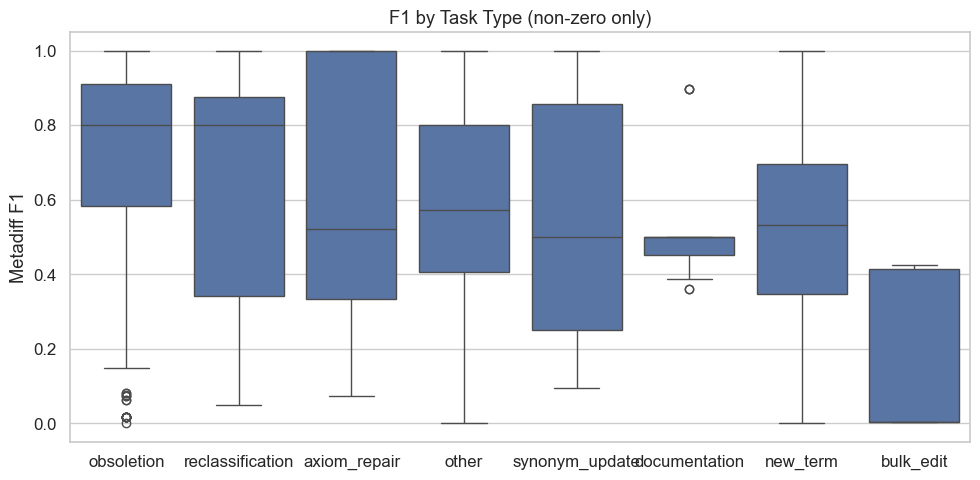

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
task_order = df[df['f1']>0].groupby('case_type')['f1'].mean().sort_values(ascending=False).index
sns.boxplot(data=df[df['f1']>0], x='case_type', y='f1', order=task_order, ax=ax)
ax.set_title('F1 by Task Type (non-zero only)')
ax.set_ylabel('Metadiff F1'); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_by_task_type.png', dpi=150)
plt.show()

### By difficulty

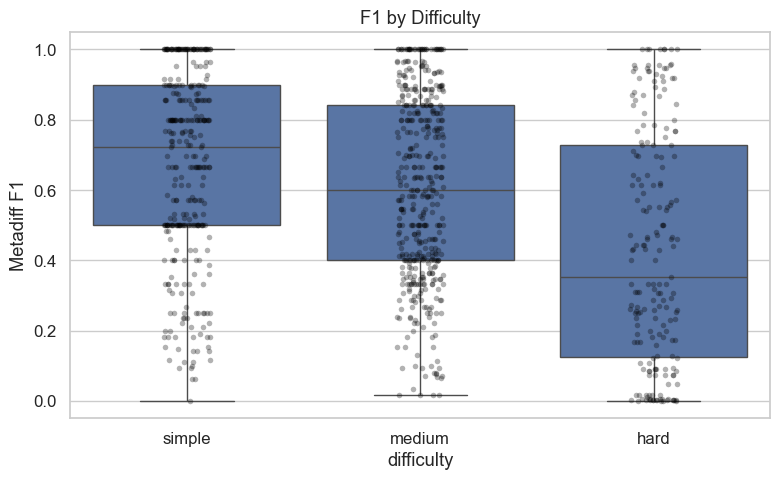

Kruskal-Wallis: H=21.07, p=0.0000
  simple  : n=413, mean=0.527, median=0.562
  medium  : n=497, mean=0.548, median=0.545
  hard    : n=207, mean=0.406, median=0.320


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[df['f1']>0], x='difficulty', y='f1', order=['simple','medium','hard'], ax=ax)
sns.stripplot(data=df[df['f1']>0], x='difficulty', y='f1', order=['simple','medium','hard'],
              color='black', alpha=0.3, size=4, ax=ax)
ax.set_title('F1 by Difficulty')
ax.set_ylabel('Metadiff F1')
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_by_difficulty.png', dpi=150)
plt.show()

# Kruskal-Wallis
groups = [df[df['difficulty']==d]['f1'].dropna().values for d in ['simple','medium','hard']]
h, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis: H={h:.2f}, p={p:.4f}')
for d in ['simple','medium','hard']:
    s = df[df['difficulty']==d]['f1']
    print(f'  {d:8s}: n={len(s)}, mean={s.mean():.3f}, median={s.median():.3f}')

### Precision vs Recall scatter

/var/folders/nc/m4tx21912kv1b8nk3zzx9plr0000gn/T/ipykernel_68926/3492733620.py:12: RuntimeWarning: divide by zero encountered in divide
  p = (f1_val*r)/(2*r - f1_val)


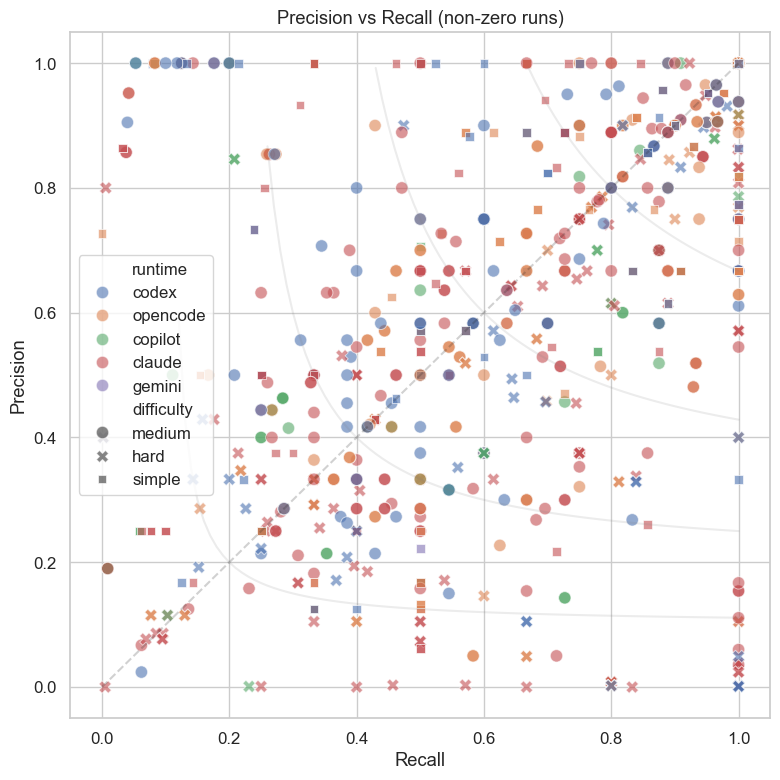

In [15]:
nonzero = df[df['f1'] > 0].copy()
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=nonzero, x='recall', y='precision', hue='runtime',
                style='difficulty', s=80, alpha=0.6, ax=ax)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.plot([0,1],[0,1],'k--',alpha=0.2)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall (non-zero runs)')
# F1 contours
for f1_val in [0.2, 0.4, 0.6, 0.8]:
    r = np.linspace(0.01,1,100)
    p = (f1_val*r)/(2*r - f1_val)
    mask = (p>0)&(p<=1)
    ax.plot(r[mask], p[mask], 'gray', alpha=0.15)
plt.tight_layout()
plt.savefig('analysis/notebooks/fig_precision_recall.png', dpi=150)
plt.show()

---
## 6. Full Results Table

Every scored run, color-coded by F1. Use this to inspect individual cases.

In [16]:
cols = ['case', 'ontology', 'case_type', 'difficulty', 'agent', 'f1', 'precision', 'recall']
full_table = df[cols].sort_values(['ontology', 'case', 'agent']).reset_index(drop=True)
full_table.style.background_gradient(subset=['f1','precision','recall'], cmap='RdYlGn', vmin=0, vmax=1)

,case,ontology,case_type,difficulty,agent,f1,precision,recall
0,cel#2844,cell-ontology,new_term,medium,std_claude_hai45,0.000000,0.000000,0.000000
1,cel#2967,cell-ontology,axiom_repair,simple,std_claude_hai45,0.500000,0.500000,0.500000
2,cel#2967,cell-ontology,axiom_repair,simple,std_claude_op47,0.500000,0.500000,0.500000
3,cel#2967,cell-ontology,axiom_repair,simple,std_claude_son45,0.500000,0.500000,0.500000
4,cel#2967,cell-ontology,axiom_repair,simple,std_codex_g54,0.333000,0.500000,0.250000
5,cel#2967,cell-ontology,axiom_repair,simple,std_codex_g55,0.333000,0.500000,0.250000
6,cel#2967,cell-ontology,axiom_repair,simple,std_opencode_g55,0.500000,0.500000,0.500000
7,cel#2967,cell-ontology,axiom_repair,simple,std_opencode_g55,0.500000,0.500000,0.500000
8,cel#2967,cell-ontology,axiom_repair,simple,std_opencode_gem4,0.500000,0.500000,0.500000
9,cel#3196,cell-ontology,new_term,medium,std_claude_hai45,0.000000,0.000000,0.000000


### Pivot: Case × Agent

In [17]:
# Only standard agents, in logical order
std_agents = [a for a in AGENT_ORDER if a in df['agent'].unique()]
pivot = df[df['agent'].isin(std_agents)].pivot_table(
    values='f1', index='case', columns='agent', aggfunc='mean'
)[std_agents].round(3)
pivot.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1)

agent,std_claude_op47,std_claude_son45,std_copilot_son45,std_claude_hai45,std_opencode_g55,std_codex_g55,std_codex_g54,std_opencode_kimi,std_opencode_gem4
case,,,,,,,,,
cel#2844,nan,nan,nan,0.000000,nan,nan,nan,nan,nan
cel#2967,0.500000,0.500000,nan,0.500000,0.500000,0.333000,0.333000,nan,0.500000
cel#3196,0.000000,0.000000,nan,0.000000,0.000000,nan,0.231000,nan,nan
cel#3239,0.235000,0.412000,nan,0.353000,0.333000,0.316000,0.343000,nan,0.333000
cel#3243,0.357000,0.600000,nan,0.480000,0.545000,0.450000,nan,nan,nan
cel#3252,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,nan,nan
cel#3259,0.000000,0.000000,nan,0.706000,0.696000,0.636000,0.000000,nan,nan
cel#3267,0.361000,0.387000,nan,0.467000,0.897000,0.361000,0.897000,nan,nan
cel#3332,0.425000,0.425000,nan,0.414000,0.414000,0.235000,0.407000,nan,nan


### Side-by-side: F1 / Precision / Recall per agent

Each agent has three sub-columns (f1, pr, rc). Blank cells = agent not run on that case.

In [18]:
# Build multi-level column pivot: case × (agent × metric)
std_agents = [a for a in AGENT_ORDER if a in df['agent'].unique()]
records = []
for _, row in df[df['agent'].isin(std_agents)].iterrows():
    records.append({
        'case': row['case'],
        'type': row['case_type'],
        'diff': row['difficulty'],
        'agent': row['agent'],
        'f1': row['f1'],
        'pr': row['precision'],
        'rc': row['recall'],
    })

wide = pd.DataFrame(records)
pivot_f1 = wide.pivot_table(values='f1', index=['case','type','diff'], columns='agent', aggfunc='mean')
pivot_pr = wide.pivot_table(values='pr', index=['case','type','diff'], columns='agent', aggfunc='mean')
pivot_rc = wide.pivot_table(values='rc', index=['case','type','diff'], columns='agent', aggfunc='mean')

combined = pd.concat({
    agent: pd.DataFrame({
        'f1': pivot_f1[agent] if agent in pivot_f1.columns else np.nan,
        'pr': pivot_pr[agent] if agent in pivot_pr.columns else np.nan,
        'rc': pivot_rc[agent] if agent in pivot_rc.columns else np.nan,
    })
    for agent in std_agents
}, axis=1).round(3)

combined = combined.sort_index()

def highlight_f1(val):
    if pd.isna(val): return ''
    if val >= 0.8: return 'background-color: #a8e6a8'
    if val >= 0.5: return 'background-color: #ffffb3'
    if val > 0: return 'background-color: #ffcccc'
    return 'background-color: #ff9999'

f1_cols = [(agent, 'f1') for agent in std_agents]
combined.style.format('{:.2f}', na_rep='').map(highlight_f1, subset=f1_cols)

### Per-ontology agent comparison

In [19]:
for ont in sorted(df['ontology'].unique()):
    sub = df[df['ontology']==ont]
    print(f'\n=== {ont} ({sub["case"].nunique()} cases, {len(sub)} runs) ===')
    print(sub.groupby('agent')['f1'].agg(['count','mean','std']).round(3).sort_values('mean', ascending=False).to_string())


=== cell-ontology (37 cases, 186 runs) ===
                   count   mean    std
agent                                 
std_copilot_son45      5  0.534  0.505
std_opencode_g55      37  0.416  0.317
std_claude_op47       32  0.379  0.324
std_claude_son45      38  0.371  0.291
std_opencode_gem4      4  0.351  0.254
std_codex_g55         20  0.331  0.279
std_codex_g54         13  0.329  0.288
std_claude_hai45      37  0.327  0.323

=== go-ontology (35 cases, 357 runs) ===
                            count   mean    std
agent                                          
codex/claude-sonnet-4.5/v9      1  0.800    NaN
std_opencode_g55               60  0.763  0.291
opencode/gpt-5.4/v9             2  0.762  0.000
std_codex_g55                  39  0.755  0.283
std_codex_g54                  31  0.752  0.241
std_claude_op47                35  0.718  0.347
std_opencode_kimi              34  0.714  0.327
std_claude_son45               40  0.698  0.311
std_claude_hai45               35  0.689  0.